Author: Aiman Ishaq
Date: May 2026
Tools: Python, pandas, matplotlib, seaborn
Dataset: Iris Dataset (150 rows × 5 columns)

Load the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# loading Iris dataset from seaborn
iris = sns.load_dataset('iris')

Explore Dataset Structure

In [2]:
# shape : rows and columns
print("Shape:" , iris.shape)

# column names
print("\nColumns:" , iris.columns.tolist())

# First 5 rows
print("\nFirst 5 rows:\n", iris.head())

# datatypes and non-null counts
print("\nDataset info:")
print(iris.info())

# statistical summary
print("\nStatistical summary:\n", iris.describe())

# Check for missing values
print("\nMissing values:\n", iris.isnull().sum())

print("\nSpecies Count:\n", iris['species'].value_counts())

Shape: (150, 5)

Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:
    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
None

Statistical summary:
        sepal_le

Scatter plot to Analyze Relationships Between Variables

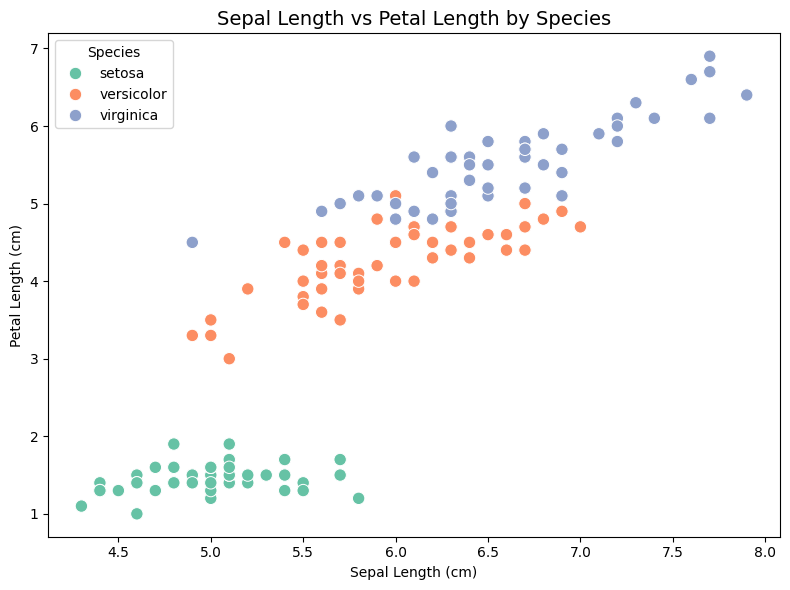

Scatter plot saved.


In [3]:

# Create plots directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='petal_length',
    hue='species',           # Color-code by species
    palette='Set2',
    s=80                     # Dot size
)

plt.title('Sepal Length vs Petal Length by Species', fontsize=14)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.savefig('plots/scatter_plot.png', dpi=150)
plt.show()
print("Scatter plot saved.")

Histogram to Examine Data Distribution

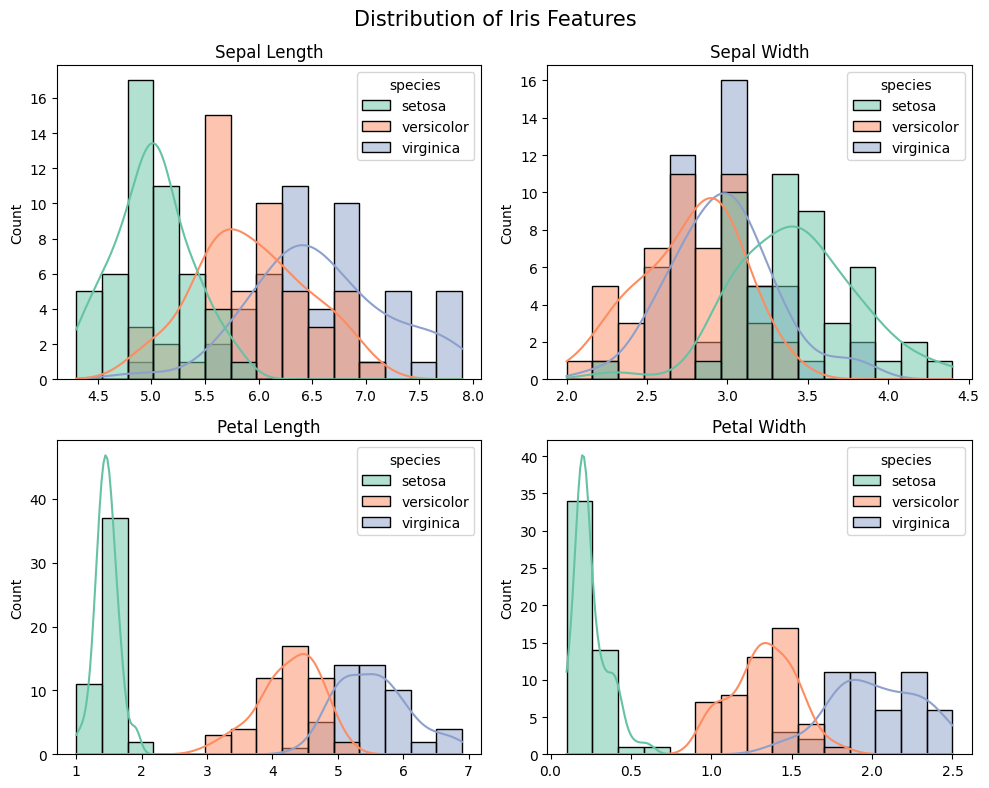

Histogram saved.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Distribution of Iris Features', fontsize=15)

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.histplot(
        data=iris,
        x=feature,
        hue='species',
        kde=True,              # Overlay smooth density curve
        palette='Set2',
        ax=ax,
        bins=15
    )
    ax.set_title(feature.replace('_', ' ').title())
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('plots/histogram.png', dpi=150)
plt.show()
print("Histogram saved.")

Box Plot to Detect Outliers and Spread

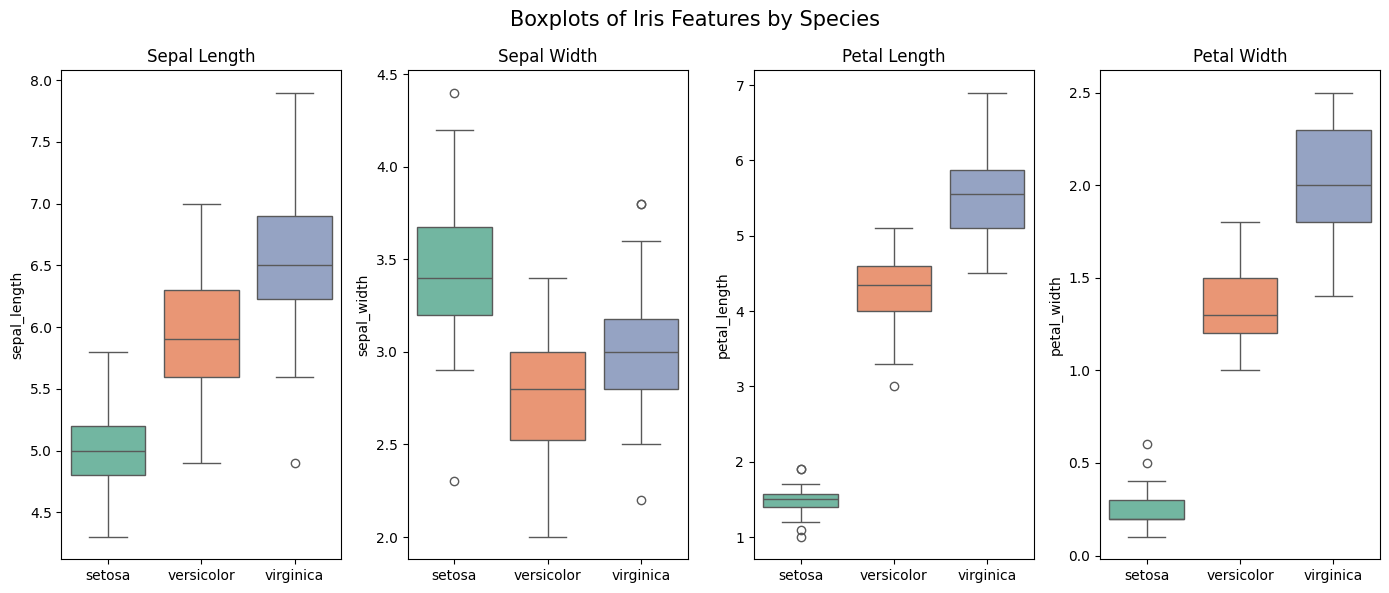

Box plot saved.


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(14, 6))
fig.suptitle('Boxplots of Iris Features by Species', fontsize=15)

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    sns.boxplot(
        data=iris,
        x='species',
        y=feature,
        hue='species',      
        palette='Set2',
        legend=False,        
        ax=axes[i]
    )
    axes[i].set_title(feature.replace('_', ' ').title())
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('plots/boxplot.png', dpi=150)
plt.show()
print("Box plot saved.")

Correlation Heatmap

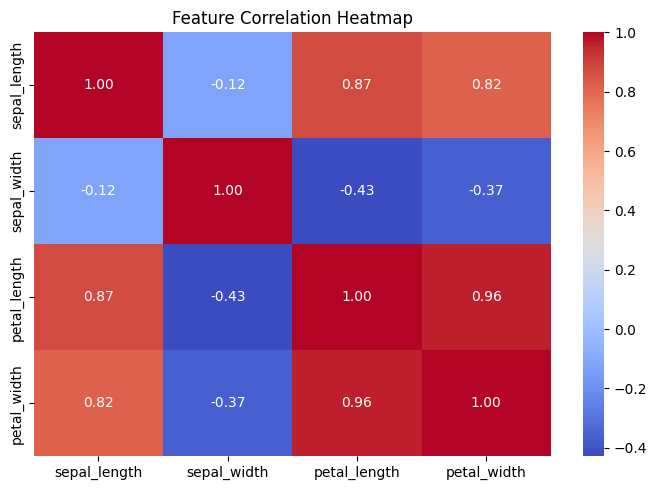

Heatmap saved.


In [6]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    iris.drop(columns='species').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/heatmap.png', dpi=150)
plt.show()
print("Heatmap saved.")

Summary of Findings

- Dataset contains 150 rows and 5 columns, 4 numeric features + 1 categorical (species)
- No missing values across all columns. dataset is clean, no preprocessing needed
- Each species has exactly 50 samples (perfectly balanced dataset)
- Setosa has the smallest petal length (avg ~1.46 cm)  separates cleanly from other species
- Virginica has the largest petal length (avg ~5.55 cm) and petal width (avg ~2.03 cm)
- Petal length and width show the strongest separation between species (visible in scatter + box plots)
- Sepal width shows the most overlap between species and contains a few outliers (visible in box plot)
- Strong positive correlation between sepal length and petal length across all species